# 06 · Similarity-Preserving Knowledge Distillation for Student-120

This notebook implements Tung and Mori's **Similarity-Preserving Knowledge Distillation (SPKD)**
as the first relation-based experiment in the project. It asks one isolated question:

> Does matching the teacher's within-batch representation geometry improve the strong,
> ImageNet-initialized Student-120 without changing its deployable graph?

The primary comparison is `sp_control` versus `similarity_preserving`. Both branches fork from the
same Stage-A checkpoint, see identical RGB augmentation seeds, use the same optimizer and budget,
and differ only by the SP loss. Response KD is deliberately excluded.

## Paper-derived workflow

```mermaid
flowchart LR
    I[Native RGB image] --> A[One shared augmentation policy]
    A --> T[Teacher branch<br/>160x160]
    A --> S[Student branch<br/>120x120]
    T --> TF[Teacher final convolution<br/>flatten each example]
    S --> SF[Student final convolution<br/>flatten each example]
    TF --> TG[Teacher b x b Gram matrix<br/>row L2 normalization]
    SF --> SG[Student b x b Gram matrix<br/>row L2 normalization]
    TG --> SP[Mean squared relation loss]
    SG --> SP
    Y[Hard VWW label] --> CE[Binary cross-entropy]
    CE --> U[Update student only]
    SP --> U
    U --> D[Student-only deployable graph]
```

SPKD does not force student features to have the same width or spatial size as teacher features.
It preserves how examples relate to one another inside a mini-batch.

## Paper equations and adaptation register

For a batch of feature tensors, flatten every sample into one row:

$$Q_T\in\mathbb{R}^{b\times d_T},\qquad Q_S\in\mathbb{R}^{b\times d_S}.$$

The feature dimensions may differ. Form a Gram matrix and normalize each row:

$$\widetilde G=QQ^\top,\qquad
G_{i,:}=\frac{\widetilde G_{i,:}}{\lVert\widetilde G_{i,:}\rVert_2}.$$

For one teacher/student layer pair, the paper's Equation (4) is:

$$L_{SP}=\frac{1}{b^2}\lVert G_T-G_S\rVert_F^2.$$

The student objective follows Equation (5):

$$L=L_{CE}+\gamma L_{SP}+L_{reg}.$$

| Decision | Paper | This notebook | Reason |
|---|---|---|---|
| Relation | Row-normalized sample Gram matrix | Exact | Core SPKD mechanism |
| Layer | Corresponding teacher/student blocks | Final convolution, `conv_pw_13_relu` | Paper uses late features; different dimensions are valid |
| Supervision | Cross-entropy + SP | Binary BCE + SP | VWW is binary |
| Coefficient | Selected on held-out data; architecture-dependent | One-time initial gradient calibration to 10% | Avoid importing CIFAR-scale `gamma=3000` blindly |
| Initialization | Architecture-specific | ImageNet Student-120 | Strong repository control and fair project comparison |
| Batch size | 128 in primary experiments | 32 | Host-memory constraint; recorded as a limitation |

The gradient calibration changes only the coefficient-selection procedure—not the SP relation or
loss. It is computed once before either Stage-B branch is trained and never tuned on the test set.

## 1 · Environment, run switches, and immutable contract

In [1]:
import os
from pathlib import Path

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
os.environ.setdefault("MPLCONFIGDIR", "/tmp/vww-matplotlib")

ROOT = Path.cwd()
while not (ROOT / "configs").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
assert (ROOT / "configs").exists(), "Run from this repository or a child directory."

import sys
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

In [2]:
import hashlib
import json
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import yaml
from IPython.display import display
from sklearn.metrics import (
    average_precision_score,
    f1_score,
    precision_recall_curve,
    roc_curve,
)

from vww_esp32.evaluation import (
    classification_metrics,
    expected_calibration_error,
    select_threshold,
)
from vww_esp32.exporting import convert_full_integer, inspect_tflite
from vww_esp32.profiling import profile_model

sns.set_theme(style="whitegrid", context="talk")

In [3]:
CONFIG_PATH = ROOT / "configs/distillation_similarity_preserving_120.yaml"

In [4]:
config = yaml.safe_load(CONFIG_PATH.read_text(encoding="utf-8"))

SEED = int(config["project"]["seed"])
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception as exc:
    print("Determinism warning:", exc)

ARTIFACT_DIR = ROOT / config["paths"]["artifacts"]
CHECKPOINT_DIR = ARTIFACT_DIR / "checkpoints"
MODEL_DIR = ARTIFACT_DIR / "models"
REPORT_DIR = ARTIFACT_DIR / "reports"
FIGURE_DIR = ARTIFACT_DIR / "figures"
LOG_DIR = ARTIFACT_DIR / "logs"
for directory in (CHECKPOINT_DIR, MODEL_DIR, REPORT_DIR, FIGURE_DIR, LOG_DIR):
    directory.mkdir(parents=True, exist_ok=True)

TEACHER_SIZE = tuple(config["data"]["teacher_size"])
STUDENT_SIZE = tuple(config["data"]["student_size"])
BATCH_SIZE = int(config["data"]["batch_size"])
AUTOTUNE = tf.data.AUTOTUNE

# First run: leave these values as shown. A report-only rerun can set
# REUSE_CHECKPOINTS=True after restarting the kernel.
RUN_TRAINING = True
REUSE_CHECKPOINTS = False
RUN_INT8_EXPORT = True

In [5]:
def sha256_file(path, chunk_bytes=1 << 20):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(chunk_bytes), b""):
            digest.update(chunk)
    return digest.hexdigest()


paths = {key: ROOT / value for key, value in config["paths"].items() if key != "artifacts"}
for key, path in paths.items():
    assert path.exists(), f"Missing {key}: {path}"

contract = {
    "config_sha256": sha256_file(CONFIG_PATH),
    "manifest_sha256": sha256_file(paths["manifest"]),
    "teacher_sha256": sha256_file(paths["teacher_model"]),
    "champion_sha256": sha256_file(paths["champion_model"]),
    "paper_sha256": sha256_file(paths["spkd_paper"]),
    "seed": SEED,
    "teacher_size": TEACHER_SIZE,
    "student_size": STUDENT_SIZE,
    "batch_size": BATCH_SIZE,
    "tensorflow": tf.__version__,
    "python": sys.version.split()[0],
}
(REPORT_DIR / "runtime_contract.json").write_text(json.dumps(contract, indent=2), encoding="utf-8")
display(pd.Series(contract, name="value"))

config_sha256      adc639ca13ca3e8afb54a15264df9b16d16d3b98a45c13...
manifest_sha256    6e25ac1d8c6b98ccc54f188e7d38ce34c9c711d1bc2242...
teacher_sha256     8f8e0d7035e58abb710f8472ca5869bc14ebbd6dfea03c...
champion_sha256    88e98014baab353bb6eb6df9280e4f993de34adf75dcb9...
paper_sha256       1234b07ab4fabedd4cf079dbf4d1ee19a3a53ebf2fea06...
seed                                                              42
teacher_size                                              (160, 160)
student_size                                              (120, 120)
batch_size                                                        32
tensorflow                                                    2.20.0
python                                                       3.10.13
Name: value, dtype: object

## 2 · Frozen data split and same-view RGB pipeline

In [6]:
manifest = pd.read_csv(paths["manifest"])
required_columns = {"image_id", "image_path", "split", "label"}
assert required_columns.issubset(manifest.columns), required_columns - set(manifest.columns)
assert manifest["image_id"].is_unique

manifest["image_path"] = manifest["image_path"].map(
    lambda value: str((ROOT / value).resolve()) if not Path(value).is_absolute() else value
)
assert manifest["image_path"].map(lambda value: Path(value).exists()).all()

splits = {
    name: frame.reset_index(drop=True)
    for name, frame in manifest.groupby("split", sort=False)
}
dataset_summary = pd.DataFrame(
    [
        {
            "split": name,
            "samples": len(frame),
            "person_samples": int(frame["label"].sum()),
            "person_fraction": float(frame["label"].mean()),
        }
        for name, frame in splits.items()
    ]
)
dataset_summary.to_csv(REPORT_DIR / "dataset_summary.csv", index=False)
display(dataset_summary)

,split,samples,person_samples,person_fraction
0,test,2000,981,0.4905
1,train,12000,6000,0.5000
2,val,2000,989,0.4945


In [7]:
def build_augmentation(seed):
    settings = config["augmentation"]
    return tf.keras.Sequential(
        [
            tf.keras.layers.RandomFlip("horizontal", seed=seed),
            tf.keras.layers.RandomTranslation(
                settings["translation_fraction"],
                settings["translation_fraction"],
                fill_mode="reflect",
                seed=seed + 1,
            ),
            tf.keras.layers.RandomBrightness(
                settings["brightness_delta"], 
                value_range=(0.0, 1.0), 
                seed=seed + 2
            ),
            tf.keras.layers.RandomContrast(
                settings["contrast_factor"], 
                seed=seed + 3
            ),
            tf.keras.layers.RandomSaturation(
                (1 - settings["saturation_delta"], 1 + settings["saturation_delta"]),
                value_range=(0.0, 1.0),
                seed=seed + 4,
            ),
            tf.keras.layers.GaussianNoise(settings["sensor_noise_stddev"], seed=seed + 5),
        ],
        name=f"shared_rgb_augmentation_{seed}",
    )


def decode_rgb(path):
    image = tf.io.decode_image(tf.io.read_file(path), channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    return tf.cast(image, tf.float32)


def make_dataset(
        frame, 
        training, 
        seed, 
        batch_size=BATCH_SIZE
):
    augmentation = build_augmentation(seed)
    dataset = tf.data.Dataset.from_tensor_slices(
        (frame["image_path"].astype(str), frame["label"].astype("float32"))
    )
    if training:
        dataset = dataset.shuffle(
            min(len(frame), 4096), seed=seed, reshuffle_each_iteration=True
        )

    def prepare(path, label):
        # A single augmented semantic view feeds both resolutions.
        base = tf.image.resize_with_pad(decode_rgb(path), *TEACHER_SIZE, antialias=True) / 255.0
        if training:
            base = augmentation(base, training=True)
        base = tf.clip_by_value(base, 0.0, 1.0)
        return {
            "teacher_image": base * 255.0,
            "student_image": tf.image.resize(base, STUDENT_SIZE, antialias=True) * 255.0,
        }, tf.reshape(label, (1,))

    return (
        dataset.map(prepare, num_parallel_calls=AUTOTUNE)
        .batch(batch_size)
        .prefetch(AUTOTUNE)
    )

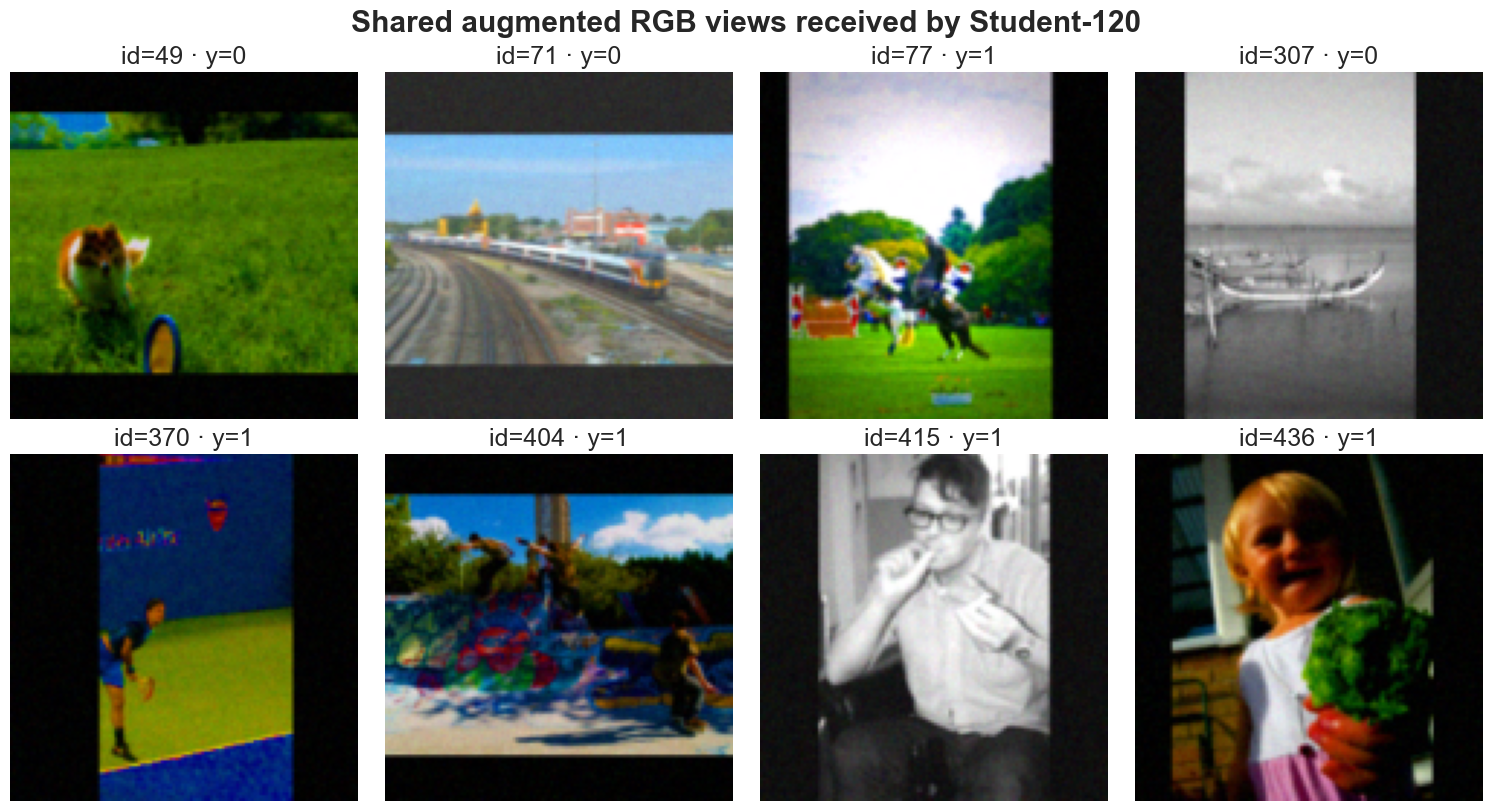

Mean within-pixel channel standard deviation: 15.673758506774902


In [8]:
preview_inputs, preview_labels = next(
    iter(make_dataset(splits["train"].iloc[:8], training=True, seed=SEED, batch_size=8))
)
fig, axes = plt.subplots(2, 4, figsize=(15, 8), constrained_layout=True)
for index, axis in enumerate(axes.flat):
    axis.imshow(np.clip(preview_inputs["student_image"][index] / 255.0, 0, 1))
    axis.set_title(f"id={splits['train'].iloc[index].image_id} · y={int(preview_labels[index, 0])}")
    axis.axis("off")
fig.suptitle("Shared augmented RGB views received by Student-120", fontweight="bold")
fig.savefig(FIGURE_DIR / "shared_rgb_views.png", dpi=180)
plt.show()

channel_spread = tf.reduce_mean(tf.math.reduce_std(preview_inputs["student_image"], axis=-1))
assert float(channel_spread) > 0.0, "Unexpected grayscale-like tensor: inspect RGB decoding."
print("Mean within-pixel channel standard deviation:", float(channel_spread))

## 3 · Teacher, champion, and exact Student-120 architecture

In [9]:
teacher = tf.keras.models.load_model(paths["teacher_model"], compile=False)
teacher.trainable = False

In [10]:
champion = tf.keras.models.load_model(paths["champion_model"], compile=False)

In [11]:
teacher_layer = config["similarity_preserving"]["teacher_layer"]
student_layer = config["similarity_preserving"]["student_layer"]
assert teacher.get_layer(teacher_layer)
assert champion.get_layer(student_layer)

In [12]:
def build_student_core(weights="imagenet"):
    image = tf.keras.Input((*STUDENT_SIZE, 3), name="image")
    normalized = tf.keras.layers.Rescaling(1 / 127.5, offset=-1, name="normalize")(image)
    backbone = tf.keras.applications.MobileNet(
        input_tensor=normalized,
        input_shape=(*STUDENT_SIZE, 3),
        alpha=float(config["student"]["width_multiplier"]),
        include_top=False,
        weights=weights,
    )
    features = tf.keras.layers.GlobalAveragePooling2D(name="global_average")(backbone.output)
    features = tf.keras.layers.Dropout(
        float(config["student"]["dropout"]), name="student_dropout"
    )(features)
    logits = tf.keras.layers.Dense(
        1,
        kernel_regularizer=tf.keras.regularizers.l2(float(config["student"]["l2"])),
        name="person_logit",
    )(features)
    core = tf.keras.Model(image, logits, name="student_120_spkd_logits")
    return core, backbone

In [13]:
def probability_view(core, name):
    probability = tf.keras.layers.Activation("sigmoid", name="person_probability")(core.output)
    return tf.keras.Model(core.input, probability, name=name)


def feature_view(model, layer_name):
    return tf.keras.Model(
        model.input,
        [model.output, model.get_layer(layer_name).output],
        name=f"{model.name}_{layer_name}_view",
    )

In [14]:
tf.keras.utils.set_random_seed(SEED)
probe_core, _ = build_student_core(weights=None)
probe = probability_view(probe_core, "student_120_spkd_probe")
assert probe.count_params() == champion.count_params() == 218801

layer_table, liveness, static_profile = profile_model(
    probe, batch_size=1, training_batch_size=BATCH_SIZE
)
layer_table.to_csv(REPORT_DIR / "student_layer_profile.csv", index=False)
liveness.to_csv(REPORT_DIR / "student_activation_liveness.csv", index=False)
(REPORT_DIR / "student_static_profile.json").write_text(
    json.dumps(static_profile, indent=2), encoding="utf-8"
)
display(pd.Series(static_profile))

model_name                                                                        student_120_spkd_probe
layers                                                                                                91
parameters                                                                                        218801
trainable_parameters                                                                              213329
non_trainable_parameters                                                                            5472
float32_weight_bytes                                                                              875204
global_weight_sparsity                                                                          0.025014
global_weight_near_zero_fraction                                                                0.025014
global_kernel_sparsity                                                                               0.0
global_kernel_near_zero_fraction                       

In [15]:
stage_audit = pd.DataFrame(
    [
        {
            "network": "teacher",
            "layer": teacher_layer,
            "shape": str(tuple(teacher.get_layer(teacher_layer).output.shape)),
            "input": str(teacher.input_shape),
        },
        {
            "network": "student",
            "layer": student_layer,
            "shape": str(tuple(champion.get_layer(student_layer).output.shape)),
            "input": str(champion.input_shape),
        },
    ]
)
stage_audit.to_csv(REPORT_DIR / "spkd_stage_audit.csv", index=False)
display(stage_audit)

,network,layer,shape,input
0,teacher,conv_pw_13_relu,"(None, 5, 5, 512)","(None, 160, 160, 3)"
1,student,conv_pw_13_relu,"(None, 3, 3, 256)","(None, 120, 120, 3)"


## 4 · Exact SPKD relation mathematics and unit invariants

In [16]:
EPSILON = float(config["similarity_preserving"]["epsilon"])

$$\widetilde G=QQ^\top,\qquad
G_{i,:}=\frac{\widetilde G_{i,:}}{\lVert\widetilde G_{i,:}\rVert_2}.$$

In [17]:
def similarity_matrix(features, epsilon=EPSILON):
    # Paper Eq. (3): row-normalized sample Gram matrix with shape [batch, batch].
    flattened = tf.reshape(tf.cast(features, tf.float32), [tf.shape(features)[0], -1])
    gram = tf.matmul(flattened, flattened, transpose_b=True)
    return tf.math.l2_normalize(gram, axis=1, epsilon=epsilon)

$$L_{SP}=\frac{1}{b^2}\lVert G_T-G_S\rVert_F^2.$$

In [19]:
def similarity_preserving_loss(teacher_features, student_features):
    # Paper Eq. (4) for one layer pair: ||G_T-G_S||_F^2 / batch^2.
    teacher_relation = similarity_matrix(tf.stop_gradient(teacher_features))
    student_relation = similarity_matrix(student_features)
    return tf.reduce_mean(tf.square(teacher_relation - student_relation))

In [20]:
# These checks protect the concept before expensive training begins.
rng = np.random.default_rng(SEED)
teacher_probe = tf.constant(rng.normal(size=(8, 4, 4, 8)), tf.float32)
student_probe = tf.constant(rng.normal(size=(8, 3, 3, 16)), tf.float32)

assert similarity_matrix(teacher_probe).shape == (8, 8)
assert similarity_matrix(student_probe).shape == (8, 8)
assert float(similarity_preserving_loss(teacher_probe, teacher_probe)) < 1e-8

In [21]:
# Positive feature scaling leaves the row-normalized Gram matrix unchanged.
scale_error = tf.reduce_max(
    tf.abs(similarity_matrix(teacher_probe) - similarity_matrix(7.0 * teacher_probe))
)
assert float(scale_error) < 1e-5

In [22]:
# An orthogonal feature rotation preserves Q Q^T.
flat = tf.reshape(teacher_probe, (8, -1))
orthogonal, _ = tf.linalg.qr(tf.constant(rng.normal(size=(128, 128)), tf.float32))
rotated = tf.matmul(flat, orthogonal)
rotation_error = tf.reduce_max(
    tf.abs(similarity_matrix(flat) - similarity_matrix(rotated))
)
assert float(rotation_error) < 2e-5

In [23]:
different_shape_loss = float(similarity_preserving_loss(teacher_probe, student_probe))
assert np.isfinite(different_shape_loss)
print(
    {
        "scale_invariance_max_error": float(scale_error),
        "rotation_invariance_max_error": float(rotation_error),
        "different_feature_shape_loss": different_shape_loss,
    }
)

{'scale_invariance_max_error': 1.1920928955078125e-07, 'rotation_invariance_max_error': 1.5273690223693848e-07, 'different_feature_shape_loss': 0.015591077506542206}


### How to read the relation matrix

Each row and column represents one image in the mini-batch. A bright off-diagonal cell means the
network represents two different images similarly. If samples are ordered by label, useful class
geometry often appears as two bright diagonal blocks and darker cross-class blocks. SPKD does not
receive labels through this matrix; it copies the teacher's geometry, including both useful
structure and teacher mistakes.

Because the matrix is `batch_size x batch_size`, training memory and computation scale
quadratically with batch size. With batch size 32, one float32 matrix contains 1,024 values
(4 KiB); teacher and student matrices are training-only and never reach the ESP32.

## 5 · Shared Stage A, gradient calibration, and causal Stage-B branches

In [24]:
class BestStudentCheckpoint(tf.keras.callbacks.Callback):
    def __init__(self, path):
        super().__init__()
        self.path = Path(path)
        self.best = -np.inf

    def on_epoch_end(self, epoch, logs=None):
        value = (logs or {}).get(config["training"]["monitor"])
        if value is not None and float(value) > self.best:
            self.best = float(value)
            self.model.student_core.save(self.path)

In [25]:
class EpochTimer(tf.keras.callbacks.Callback):
    def on_epoch_begin(self, epoch, logs=None):
        self.started = time.perf_counter()

    def on_epoch_end(self, epoch, logs=None):
        logs["epoch_seconds"] = time.perf_counter() - self.started


In [26]:
def callbacks(name, path):
    return [
        EpochTimer(),
        BestStudentCheckpoint(path),
        tf.keras.callbacks.EarlyStopping(
            monitor=config["training"]["monitor"],
            mode="max",
            patience=int(config["training"]["early_stopping_patience"]),
            restore_best_weights=False,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor=config["training"]["monitor"],
            mode="max",
            factor=0.3,
            patience=int(config["training"]["reduce_lr_patience"]),
            min_lr=1e-7,
        ),
        tf.keras.callbacks.CSVLogger(LOG_DIR / f"{name}.csv"),
        tf.keras.callbacks.TerminateOnNaN(),
    ]

In [27]:
class SimilarityDistiller(tf.keras.Model):
    def __init__(self, student_core, teacher_model, gamma):
        super().__init__()
        self.student_core = student_core
        self.teacher_model = teacher_model
        self.gamma = tf.constant(float(gamma), tf.float32)
        self.gamma_value = float(gamma)
        self.student_features = feature_view(student_core, student_layer)
        self.teacher_features = feature_view(teacher_model, teacher_layer)

        tracked = [
            "loss",
            "hard_loss",
            "sp_loss",
            "sp_component",
            "hard_gradient_norm",
            "sp_gradient_norm",
            "gradient_cosine",
        ]
        self.trackers = {name: tf.keras.metrics.Mean(name=name) for name in tracked}
        self.quality = [
            tf.keras.metrics.BinaryAccuracy(name="accuracy"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(curve="PR", name="pr_auc"),
        ]

    @property
    def metrics(self):
        return [*self.trackers.values(), *self.quality]

    def _terms(self, inputs, labels, training):
        logits, student_feature = self.student_features(
            inputs["student_image"], training=training
        )
        if self.gamma_value > 0:
            _, teacher_feature = self.teacher_features(
                inputs["teacher_image"], 
                training=False
            )
            sp = similarity_preserving_loss(
                teacher_feature, 
                student_feature
            )
        else:
            sp = tf.constant(0.0, tf.float32)

        labels = tf.reshape(labels, (-1, 1))

        smoothing = float(config["training"]["label_smoothing"])
        smooth_labels = labels * (1 - smoothing) + 0.5 * smoothing

        hard = tf.reduce_mean(
            tf.nn.sigmoid_cross_entropy_with_logits(
                labels=smooth_labels, 
                logits=logits
            )
        )

        regularization = tf.add_n(self.student_core.losses) if self.student_core.losses else 0.0

        total = hard + self.gamma * sp + regularization

        return logits, hard, sp, total

    @staticmethod
    def _dense_gradient_vector(gradients, variables):
        return tf.concat(
            [
                tf.reshape(gradient if gradient is not None else tf.zeros_like(variable), [-1])
                for gradient, variable in zip(gradients, variables)
            ],
            axis=0,
        )

    def train_step(self, data):
        inputs, labels = data
        with tf.GradientTape(persistent=True) as tape:
            logits, hard, sp, total = self._terms(inputs, labels, training=True)
            sp_component = self.gamma * sp

        variables = self.student_core.trainable_variables
        total_gradients = tape.gradient(total, variables)
        hard_gradients = tape.gradient(hard, variables)
        sp_gradients = tape.gradient(sp_component, variables)
        del tape

        self.optimizer.apply_gradients(
            [(gradient, variable) for gradient, variable in zip(total_gradients, variables) if gradient is not None]
        )

        hard_vector = self._dense_gradient_vector(hard_gradients, variables)
        sp_vector = self._dense_gradient_vector(sp_gradients, variables)

        cosine = tf.math.divide_no_nan(
            tf.reduce_sum(hard_vector * sp_vector), 
            tf.norm(hard_vector) * tf.norm(sp_vector)
        )

        values = {
            "loss": total,
            "hard_loss": hard,
            "sp_loss": sp,
            "sp_component": sp_component,
            "hard_gradient_norm": tf.linalg.global_norm([g for g in hard_gradients if g is not None]),
            "sp_gradient_norm": tf.linalg.global_norm([g for g in sp_gradients if g is not None]),
            "gradient_cosine": cosine,
        }
        for name, value in values.items():
            self.trackers[name].update_state(value)
        for metric in self.quality:
            metric.update_state(tf.reshape(labels, (-1, 1)), tf.sigmoid(logits))
        return {metric.name: metric.result() for metric in self.metrics}

    def test_step(self, data):
        inputs, labels = data
        logits, hard, sp, total = self._terms(inputs, labels, training=False)
        values = {
            "loss": total,
            "hard_loss": hard,
            "sp_loss": sp,
            "sp_component": self.gamma * sp,
            "hard_gradient_norm": 0.0,
            "sp_gradient_norm": 0.0,
            "gradient_cosine": 0.0,
        }
        for name, value in values.items():
            self.trackers[name].update_state(value)
        for metric in self.quality:
            metric.update_state(tf.reshape(labels, (-1, 1)), tf.sigmoid(logits))
            
        return {metric.name: metric.result() for metric in self.metrics}

In [28]:
STAGE_A = CHECKPOINT_DIR / "shared_stage_a.keras"

In [29]:
if RUN_TRAINING and not (REUSE_CHECKPOINTS and STAGE_A.exists()):
    tf.keras.utils.set_random_seed(SEED)

    stage_core, stage_backbone = build_student_core(weights=config["student"]["initialization"])

    backbone_names = {layer.name for layer in stage_backbone.layers}
    for layer in stage_core.layers:
        if layer.name in backbone_names:
            layer.trainable = False

    stage_trainer = SimilarityDistiller(
        stage_core, 
        teacher, 
        gamma=0.0
    )

    stage_trainer.compile(
        optimizer=tf.keras.optimizers.Adam(float(config["training"]["head_learning_rate"]))
    )
    
    stage_trainer.fit(
        make_dataset(splits["train"], training=True, seed=SEED),
        validation_data=make_dataset(splits["val"], training=False, seed=SEED),
        epochs=int(config["training"]["head_epochs"]),
        callbacks=callbacks("shared_stage_a", STAGE_A),
    )

assert STAGE_A.exists(), "Stage-A checkpoint was not created."

/var/folders/8s/5p551ggs4fb2kjgvk5kzysnr0000gn/T/ipykernel_32241/1335996087.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  backbone = tf.keras.applications.MobileNet(


Epoch 1/8
375/375 ━━━━━━━━━━━━━━━━━━━━ 79s 204ms/step - accuracy: 0.5164 - gradient_cosine: 0.0000e+00 - hard_gradient_norm: 3.0963 - hard_loss: 0.9654 - loss: 0.9655 - pr_auc: 0.5196 - precision: 0.5173 - recall: 0.4903 - sp_component: 0.0000e+00 - sp_gradient_norm: 0.0000e+00 - sp_loss: 0.0000e+00 - val_accuracy: 0.6150 - val_gradient_cosine: 0.0000e+00 - val_hard_gradient_norm: 0.0000e+00 - val_hard_loss: 0.7225 - val_loss: 0.7226 - val_pr_auc: 0.6238 - val_precision: 0.6024 - val_recall: 0.6512 - val_sp_component: 0.0000e+00 - val_sp_gradient_norm: 0.0000e+00 - val_sp_loss: 0.0000e+00 - epoch_seconds: 78.6380 - learning_rate: 3.0000e-04
Epoch 2/8
375/375 ━━━━━━━━━━━━━━━━━━━━ 75s 200ms/step - accuracy: 0.6154 - gradient_cosine: 0.0000e+00 - hard_gradient_norm: 2.4915 - hard_loss: 0.7380 - loss: 0.7380 - pr_auc: 0.6579 - precision: 0.6153 - recall: 0.6160 - sp_component: 0.0000e+00 - sp_gradient_norm: 0.0000e+00 - sp_loss: 0.0000e+00 - val_accuracy: 0.6820 - val_gradient_cosine: 0.00

In [30]:
def unfreeze_tail(core):
    convolution_names = [layer.name for layer in core.layers if layer.name.startswith("conv_")]
    count = int(config["training"]["fine_tune_last_layers"])
    selected = set(convolution_names[max(0, len(convolution_names) - count):])
    for layer in core.layers:
        if layer.name in selected:
            # Frozen BN statistics are more stable for this small-data fine-tuning protocol.
            layer.trainable = not isinstance(layer, tf.keras.layers.BatchNormalization)
    return core

In [31]:
def calibrate_gamma(
        core, 
        batch, 
        target_ratio
):
    inputs, labels = batch
    student_features = feature_view(core, student_layer)
    teacher_features = feature_view(teacher, teacher_layer)

    with tf.GradientTape(persistent=True) as tape:
        logits, student_feature = student_features(inputs["student_image"], training=True)
        _, teacher_feature = teacher_features(inputs["teacher_image"], training=False)

        labels = tf.reshape(labels, (-1, 1))

        hard = tf.reduce_mean(
            tf.nn.sigmoid_cross_entropy_with_logits(
                labels=labels, 
                logits=logits
            )
        )
        raw_sp = similarity_preserving_loss(
            teacher_feature, 
            student_feature
        )

    variables = core.trainable_variables
    hard_gradients = tape.gradient(hard, variables)
    sp_gradients = tape.gradient(raw_sp, variables)

    del tape

    hard_norm = float(tf.linalg.global_norm([g for g in hard_gradients if g is not None]))
    raw_sp_norm = float(tf.linalg.global_norm([g for g in sp_gradients if g is not None]))
    gamma = np.clip(
        target_ratio * hard_norm / max(raw_sp_norm, 1e-12),
        float(config["similarity_preserving"]["gamma_minimum"]),
        float(config["similarity_preserving"]["gamma_maximum"]),
    )
    
    return float(gamma), {
        "hard_gradient_norm": hard_norm,
        "raw_sp_gradient_norm": raw_sp_norm,
        "target_weighted_gradient_ratio": float(target_ratio),
        "gamma": float(gamma),
    }

In [32]:
calibration_core = unfreeze_tail(
    tf.keras.models.load_model(
        STAGE_A, 
        compile=False
    )
)
calibration_frame = splits["train"].iloc[:BATCH_SIZE]
calibration_batch = next(
    iter(make_dataset(calibration_frame, training=True, seed=SEED, batch_size=BATCH_SIZE))
)

In [33]:
GAMMA, gamma_audit = calibrate_gamma(
    calibration_core,
    calibration_batch,
    float(config["similarity_preserving"]["target_gradient_ratio"]),
)

In [34]:
(REPORT_DIR / "gamma_calibration.json").write_text(
    json.dumps(gamma_audit, indent=2), encoding="utf-8"
)
display(pd.Series(gamma_audit))

hard_gradient_norm                 8.984138
raw_sp_gradient_norm               0.048294
target_weighted_gradient_ratio     0.100000
gamma                             18.602837
dtype: float64

In [35]:
def train_stage_b_branch(name, gamma):

    checkpoint = CHECKPOINT_DIR / f"{name}_stage_b.keras"
    core = unfreeze_tail(tf.keras.models.load_model(STAGE_A, compile=False))

    if RUN_TRAINING and not (REUSE_CHECKPOINTS and checkpoint.exists()):

        tf.keras.utils.set_random_seed(SEED)

        trainer = SimilarityDistiller(
            core, 
            teacher, 
            gamma=gamma
        )
        trainer.compile(
            optimizer=tf.keras.optimizers.Adam(
                float(config["training"]["fine_tune_learning_rate"])
            )
        )
        trainer.fit(
            make_dataset(splits["train"], training=True, seed=SEED),
            validation_data=make_dataset(splits["val"], training=False, seed=SEED),
            epochs=int(config["training"]["fine_tune_epochs"]),
            callbacks=callbacks(name, checkpoint),
        )

    assert checkpoint.exists(), f"Missing checkpoint: {checkpoint}"
    best_core = tf.keras.models.load_model(checkpoint, compile=False)
    model = probability_view(best_core, name)
    model_path = MODEL_DIR / f"{name}.keras"
    model.save(model_path)
    return model_path

In [36]:
models = {
    "sp_control": train_stage_b_branch("sp_control", gamma=0.0),
    "similarity_preserving": train_stage_b_branch("similarity_preserving", gamma=GAMMA),
}
models

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 83s 214ms/step - accuracy: 0.7155 - gradient_cosine: 0.0000e+00 - hard_gradient_norm: 9.8392 - hard_loss: 0.5672 - loss: 0.5672 - pr_auc: 0.7979 - precision: 0.7220 - recall: 0.7008 - sp_component: 0.0000e+00 - sp_gradient_norm: 0.0000e+00 - sp_loss: 0.0000e+00 - val_accuracy: 0.7465 - val_gradient_cosine: 0.0000e+00 - val_hard_gradient_norm: 0.0000e+00 - val_hard_loss: 0.5281 - val_loss: 0.5281 - val_pr_auc: 0.8250 - val_precision: 0.7745 - val_recall: 0.6876 - val_sp_component: 0.0000e+00 - val_sp_gradient_norm: 0.0000e+00 - val_sp_loss: 0.0000e+00 - epoch_seconds: 82.8657 - learning_rate: 3.0000e-05
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 82s 219ms/step - accuracy: 0.7214 - gradient_cosine: 0.0000e+00 - hard_gradient_norm: 9.0712 - hard_loss: 0.5547 - loss: 0.5547 - pr_auc: 0.8054 - precision: 0.7306 - recall: 0.7015 - sp_component: 0.0000e+00 - sp_gradient_norm: 0.0000e+00 - sp_loss: 0.0000e+00 - val_accuracy: 0.7430 - val_gradient_cosine: 0.

{'sp_control': PosixPath('/Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32/artifacts/distillation/similarity_preserving_student_120/models/sp_control.keras'),
 'similarity_preserving': PosixPath('/Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32/artifacts/distillation/similarity_preserving_student_120/models/similarity_preserving.keras')}

## 6 · Optimization audit: losses, gradients, convergence, and runtime

In [37]:
history_frames = []
for run_name in ("shared_stage_a", "sp_control", "similarity_preserving"):
    log_path = LOG_DIR / f"{run_name}.csv"
    if log_path.exists():
        frame = pd.read_csv(log_path)
        frame["run"] = run_name
        frame["epoch_index"] = np.arange(1, len(frame) + 1)
        history_frames.append(frame)

history = pd.concat(history_frames, ignore_index=True)
history.to_csv(REPORT_DIR / "training_history.csv", index=False)

runtime_summary = history.groupby("run", as_index=False).agg(
    epochs=("epoch_index", "max"),
    best_validation_pr_auc=("val_pr_auc", "max"),
    final_validation_pr_auc=("val_pr_auc", "last"),
    runtime_seconds=("epoch_seconds", "sum"),
)
runtime_summary["runtime_minutes"] = runtime_summary["runtime_seconds"] / 60.0
runtime_summary.to_csv(REPORT_DIR / "training_runtime_summary.csv", index=False)
display(runtime_summary)

,run,epochs,best_validation_pr_auc,final_validation_pr_auc,runtime_seconds,runtime_minutes
0,shared_stage_a,8,0.822624,0.822624,686.766546,11.446109
1,similarity_preserving,20,0.863894,0.862131,2635.215248,43.920254
2,sp_control,20,0.863016,0.858415,1785.733039,29.762217


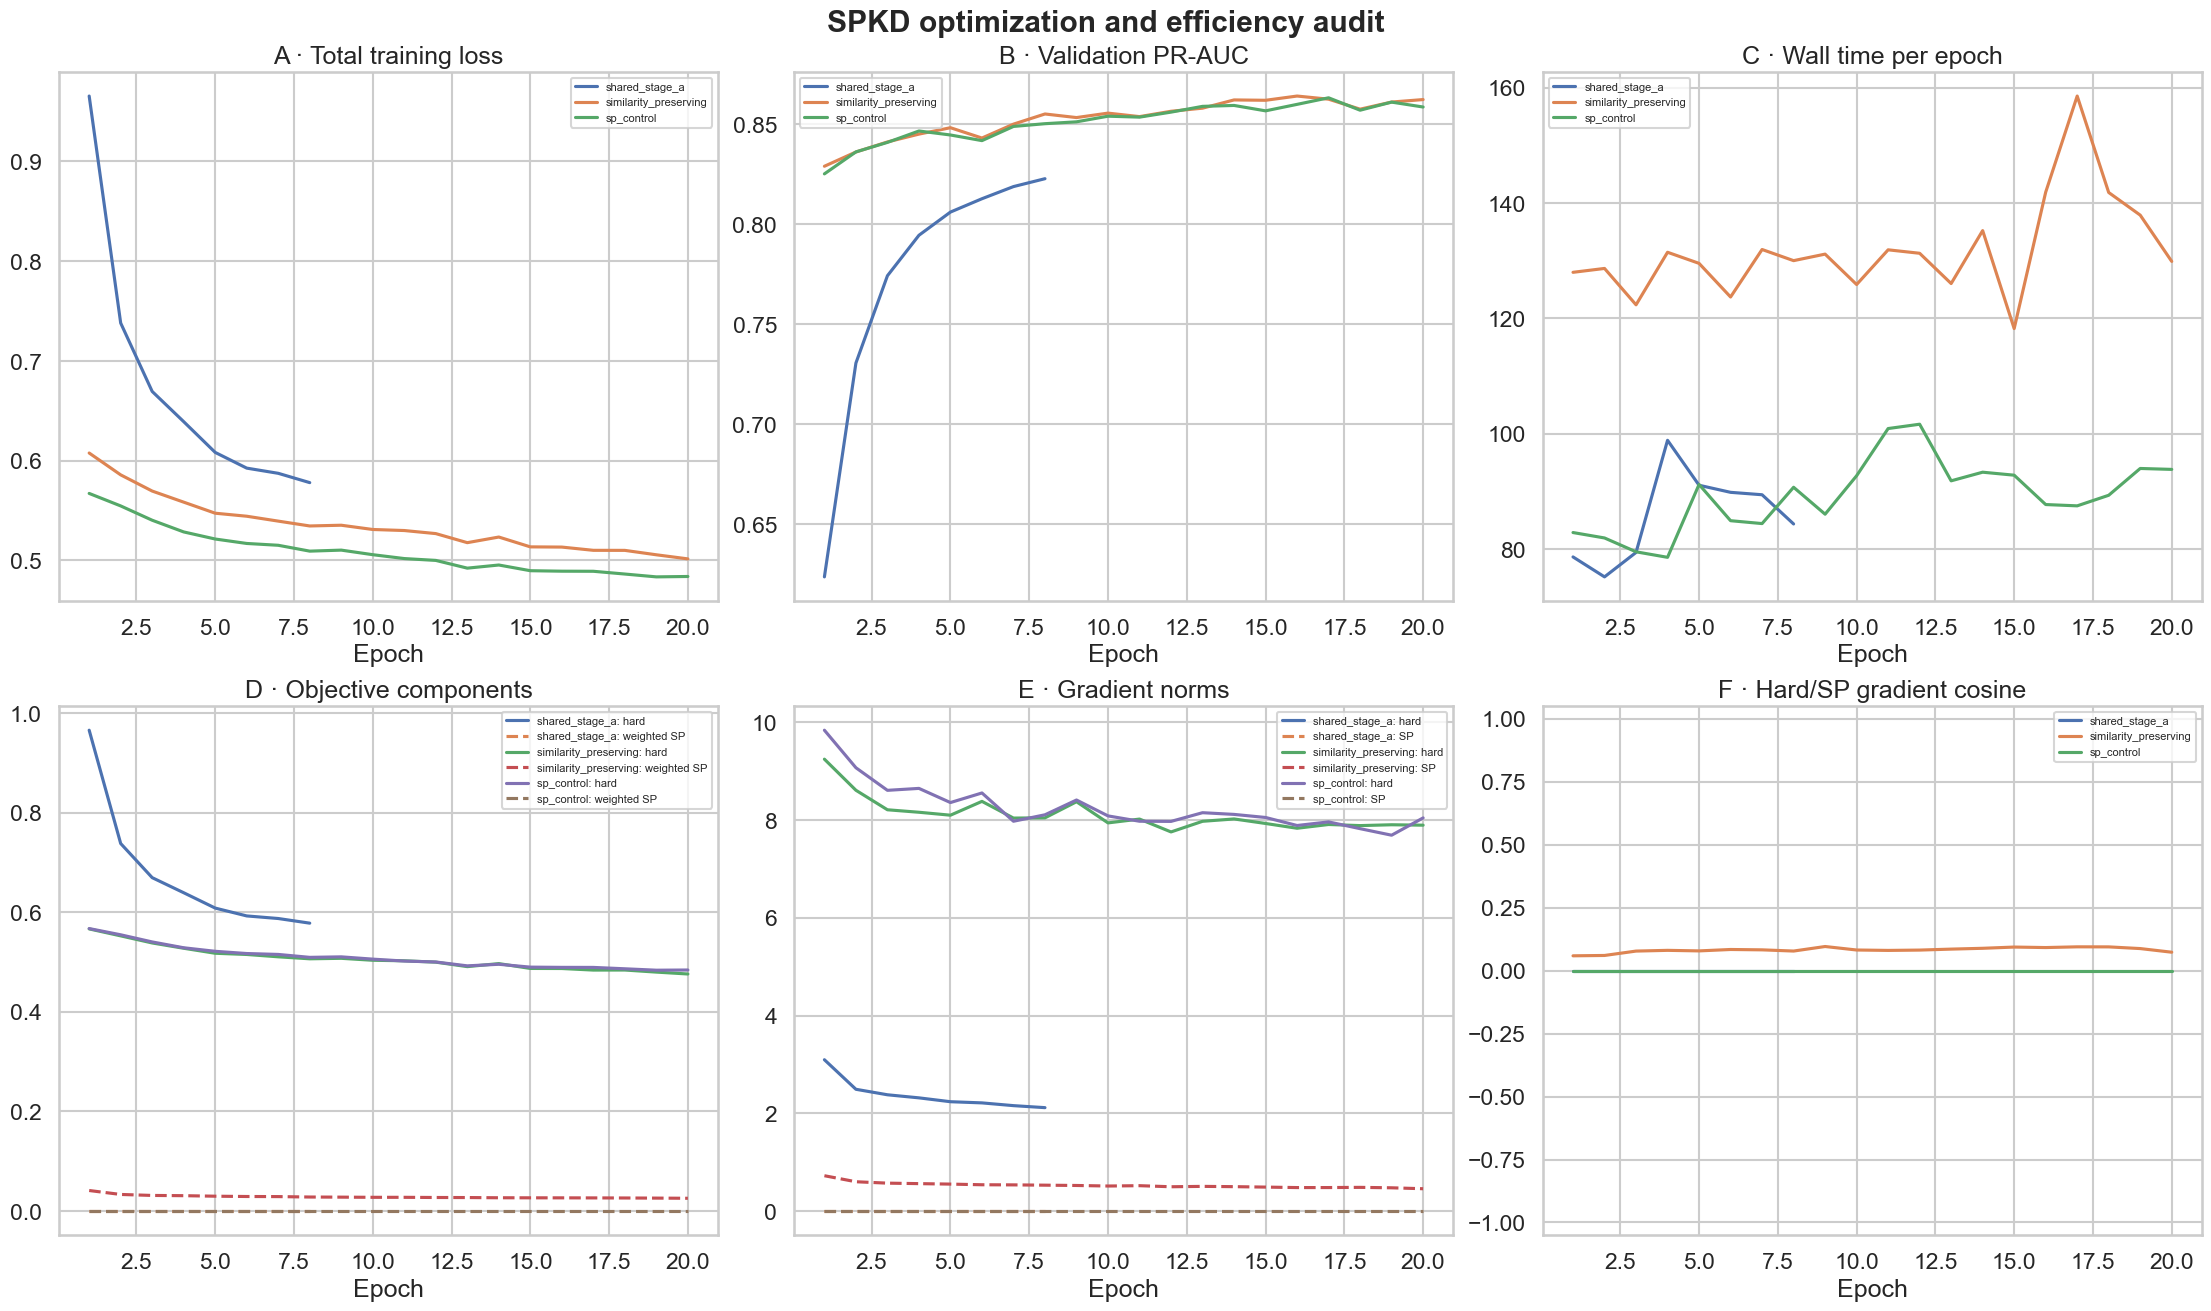

In [38]:
fig, axes = plt.subplots(2, 3, figsize=(22, 13), constrained_layout=True)
for name, frame in history.groupby("run"):
    axes[0, 0].plot(frame["epoch_index"], frame["loss"], label=name)
    axes[0, 1].plot(frame["epoch_index"], frame["val_pr_auc"], label=name)
    axes[0, 2].plot(frame["epoch_index"], frame["epoch_seconds"], label=name)
    axes[1, 0].plot(frame["epoch_index"], frame["hard_loss"], label=f"{name}: hard")
    axes[1, 0].plot(frame["epoch_index"], frame["sp_component"], "--", label=f"{name}: weighted SP")
    axes[1, 1].plot(frame["epoch_index"], frame["hard_gradient_norm"], label=f"{name}: hard")
    axes[1, 1].plot(frame["epoch_index"], frame["sp_gradient_norm"], "--", label=f"{name}: SP")
    axes[1, 2].plot(frame["epoch_index"], frame["gradient_cosine"], label=name)

titles = [
    "A · Total training loss",
    "B · Validation PR-AUC",
    "C · Wall time per epoch",
    "D · Objective components",
    "E · Gradient norms",
    "F · Hard/SP gradient cosine",
]
for axis, title in zip(axes.flat, titles):
    axis.set_title(title)
    axis.set_xlabel("Epoch")
    axis.legend(fontsize=8)
axes[1, 2].set_ylim(-1.05, 1.05)
fig.suptitle("SPKD optimization and efficiency audit", fontweight="bold")
fig.savefig(FIGURE_DIR / "spkd_training_audit.png", dpi=180)
plt.show()

## 7 · Validation-selected frozen-test quality

In [39]:
def make_eval_dataset(frame, size=STUDENT_SIZE, batch_size=BATCH_SIZE):
    dataset = tf.data.Dataset.from_tensor_slices(
        (frame["image_path"].astype(str), frame["label"].astype("float32"))
    )
    return (
        dataset.map(
            lambda path, label: (
                tf.image.resize_with_pad(decode_rgb(path), *size, antialias=True),
                label,
            ),
            num_parallel_calls=AUTOTUNE,
        )
        .batch(batch_size)
        .prefetch(AUTOTUNE)
    )

In [40]:
def predict_keras(model, dataset):
    labels = np.concatenate([np.asarray(label).reshape(-1) for _, label in dataset]).astype(int)
    probabilities = np.asarray(model.predict(dataset, verbose=0)).reshape(-1)
    return labels, probabilities

In [41]:
val_dataset = make_eval_dataset(splits["val"])
test_dataset = make_eval_dataset(splits["test"])
quality_rows = []
probabilities = {}
thresholds = {}

for name, model_path in models.items():
    model = tf.keras.models.load_model(model_path, compile=False)
    validation_labels, validation_probability = predict_keras(model, val_dataset)

    test_labels, test_probability = predict_keras(model, test_dataset)

    threshold = select_threshold(
        validation_labels,
        validation_probability,
        objective=config["evaluation"]["threshold_objective"],
        minimum_recall=float(config["evaluation"]["minimum_recall"]),
        false_positive_cost=float(config["evaluation"]["false_positive_cost"]),
        false_negative_cost=float(config["evaluation"]["false_negative_cost"]),
    )["threshold"]
    
    metrics = classification_metrics(test_labels, test_probability, threshold)
    metrics["ece_10"] = expected_calibration_error(test_labels, test_probability)
    quality_rows.append({"model": name, **metrics})
    probabilities[name] = test_probability
    thresholds[name] = float(threshold)

quality = pd.DataFrame(quality_rows)
quality.to_csv(REPORT_DIR / "quality_comparison.csv", index=False)
(REPORT_DIR / "validation_thresholds.json").write_text(
    json.dumps(thresholds, indent=2), encoding="utf-8"
)
display(quality)

,model,samples,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc,specificity,confusion_matrix,positive_prevalence,predicted_positive_rate,ece_10
0,sp_control,2000,0.305,0.7645,0.72973,0.825688,0.774749,0.861521,0.862016,0.705594,"[[719, 300], [171, 810]]",0.4905,0.5550,0.053389
1,similarity_preserving,2000,0.340,0.7590,0.71162,0.855250,0.776852,0.863289,0.863601,0.666340,"[[679, 340], [142, 839]]",0.4905,0.5895,0.016283


In [42]:
rng = np.random.default_rng(SEED)
indices = np.arange(len(test_labels))
bootstrap_records = []

for iteration in range(int(config["evaluation"]["bootstrap_samples"])):
    draw = rng.choice(indices, len(indices), replace=True)
    labels = test_labels[draw]
    control_probability = probabilities["sp_control"][draw]
    sp_probability = probabilities["similarity_preserving"][draw]
    bootstrap_records.append(
        {
            "iteration": iteration,
            "pr_auc_delta": average_precision_score(labels, sp_probability)
            - average_precision_score(labels, control_probability),
            "f1_delta": f1_score(
                labels, sp_probability >= thresholds["similarity_preserving"]
            )
            - f1_score(labels, control_probability >= thresholds["sp_control"]),
        }
    )

bootstrap = pd.DataFrame(bootstrap_records)
bootstrap.to_csv(REPORT_DIR / "paired_bootstrap.csv", index=False)
bootstrap_summary = pd.DataFrame(
    [
        {
            "metric": metric,
            "mean": float(bootstrap[metric].mean()),
            "ci_low": float(bootstrap[metric].quantile(0.025)),
            "ci_high": float(bootstrap[metric].quantile(0.975)),
            "probability_positive": float((bootstrap[metric] > 0).mean()),
        }
        for metric in ("pr_auc_delta", "f1_delta")
    ]
)
bootstrap_summary.to_csv(REPORT_DIR / "bootstrap_summary.csv", index=False)
display(bootstrap_summary)

,metric,mean,ci_low,ci_high,probability_positive
0,pr_auc_delta,0.001524,-0.003870,0.007486,0.703
1,f1_delta,0.002039,-0.008681,0.013004,0.650


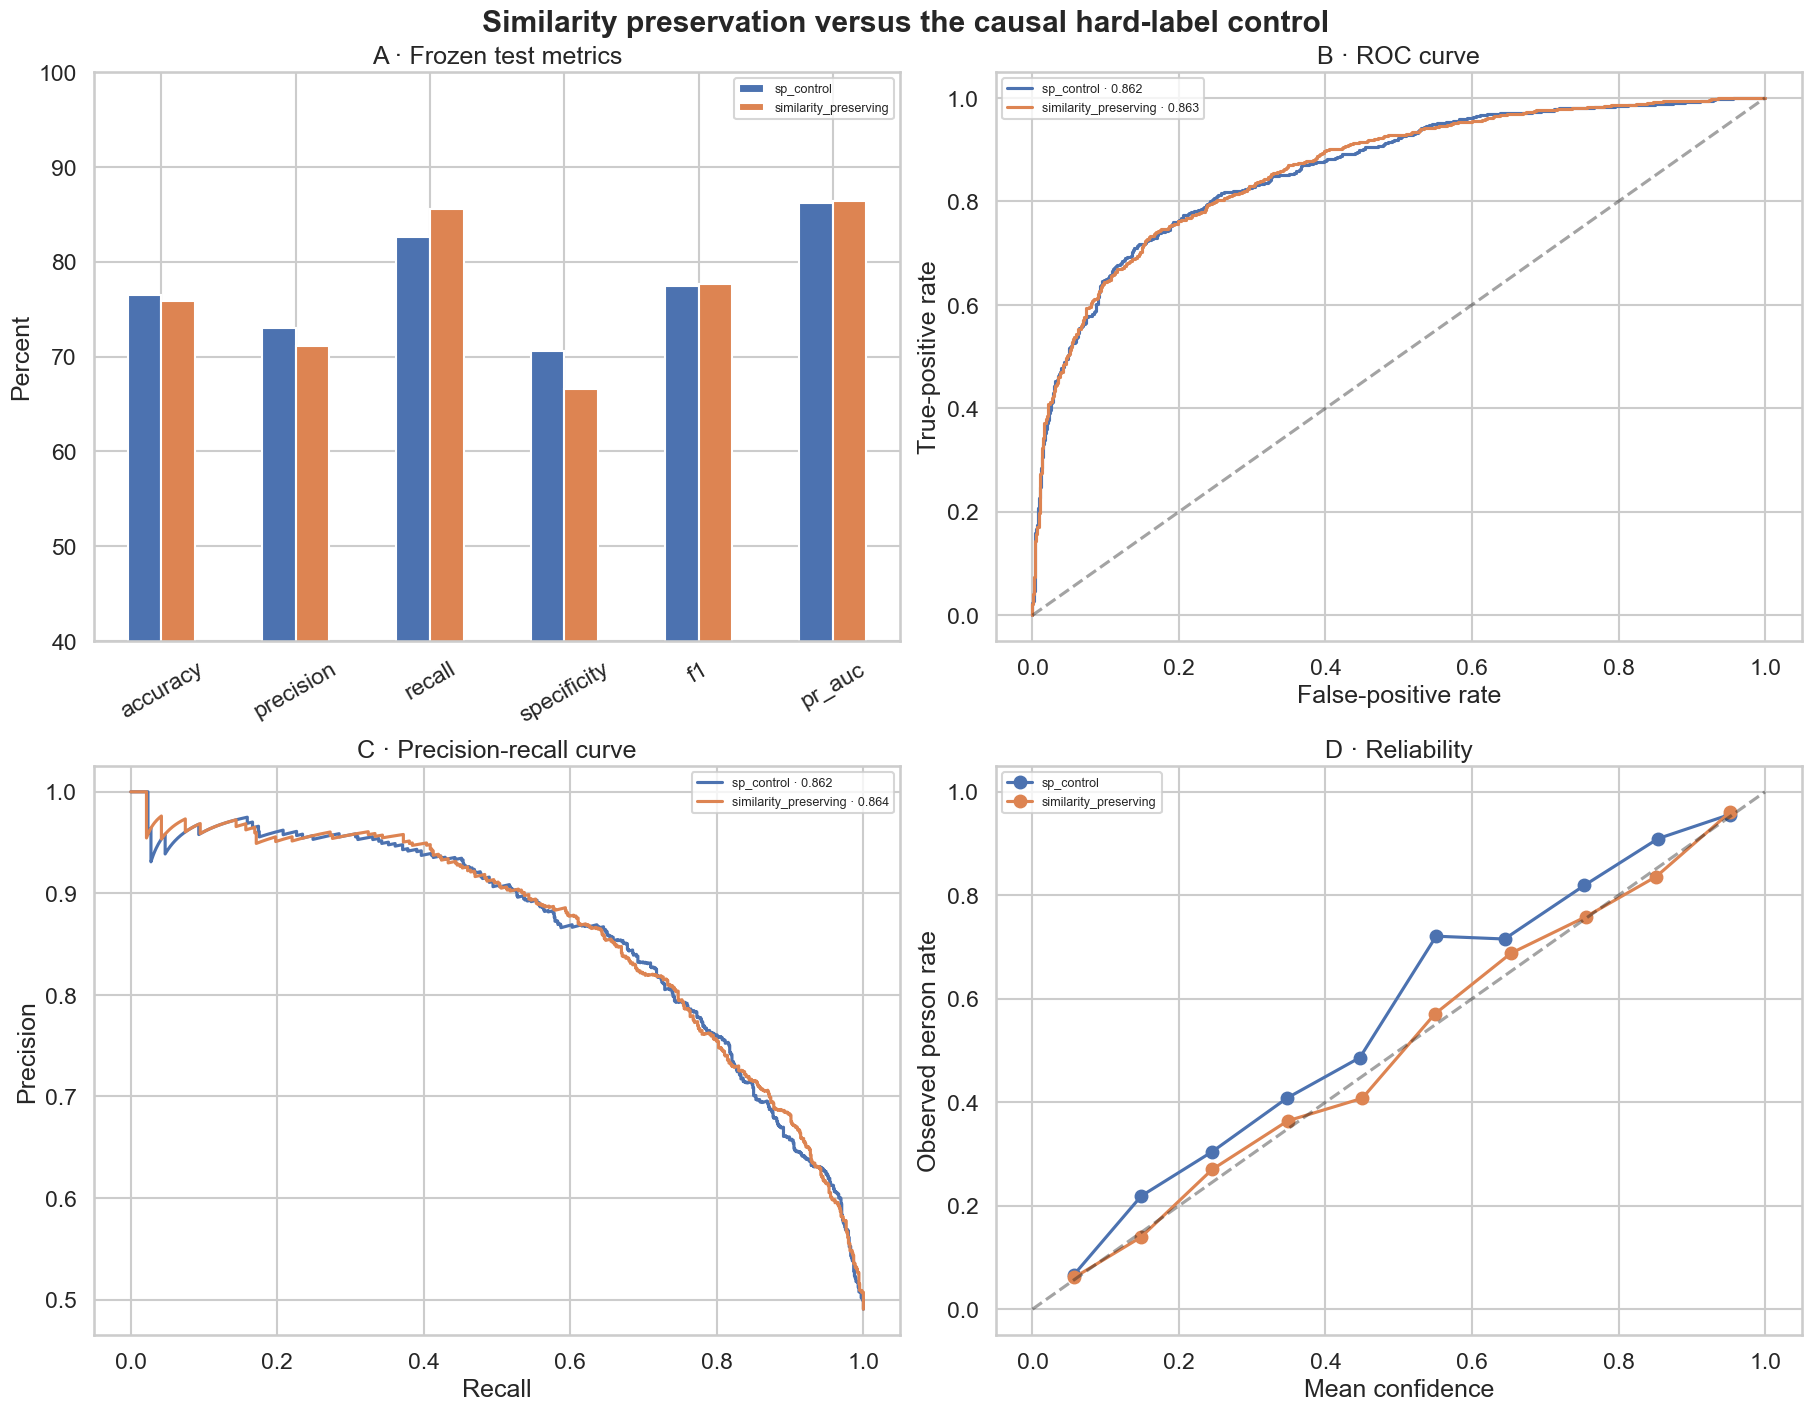

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14), constrained_layout=True)
metric_names = ["accuracy", "precision", "recall", "specificity", "f1", "pr_auc"]
(quality.set_index("model")[metric_names].T * 100).plot(kind="bar", ax=axes[0, 0])
axes[0, 0].set(title="A · Frozen test metrics", ylabel="Percent", ylim=(40, 100))
axes[0, 0].tick_params(axis="x", rotation=30)

for name in models:
    false_positive, true_positive, _ = roc_curve(test_labels, probabilities[name])
    precision, recall, _ = precision_recall_curve(test_labels, probabilities[name])
    row = quality.set_index("model").loc[name]
    axes[0, 1].plot(false_positive, true_positive, label=f"{name} · {row.roc_auc:.3f}")
    axes[1, 0].plot(recall, precision, label=f"{name} · {row.pr_auc:.3f}")

axes[0, 1].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[0, 1].set(title="B · ROC curve", xlabel="False-positive rate", ylabel="True-positive rate")
axes[1, 0].set(title="C · Precision-recall curve", xlabel="Recall", ylabel="Precision")

bins = np.linspace(0, 1, 11)
for name in models:
    probability = probabilities[name]
    bin_ids = np.clip(np.digitize(probability, bins) - 1, 0, 9)
    confidence, observed = [], []
    for bin_id in range(10):
        mask = bin_ids == bin_id
        if mask.any():
            confidence.append(probability[mask].mean())
            observed.append(test_labels[mask].mean())
    axes[1, 1].plot(confidence, observed, marker="o", label=name)
axes[1, 1].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[1, 1].set(title="D · Reliability", xlabel="Mean confidence", ylabel="Observed person rate")

for axis in axes.flat:
    axis.legend(fontsize=9)
fig.suptitle("Similarity preservation versus the causal hard-label control", fontweight="bold")
fig.savefig(FIGURE_DIR / "spkd_quality_dashboard.png", dpi=180)
plt.show()

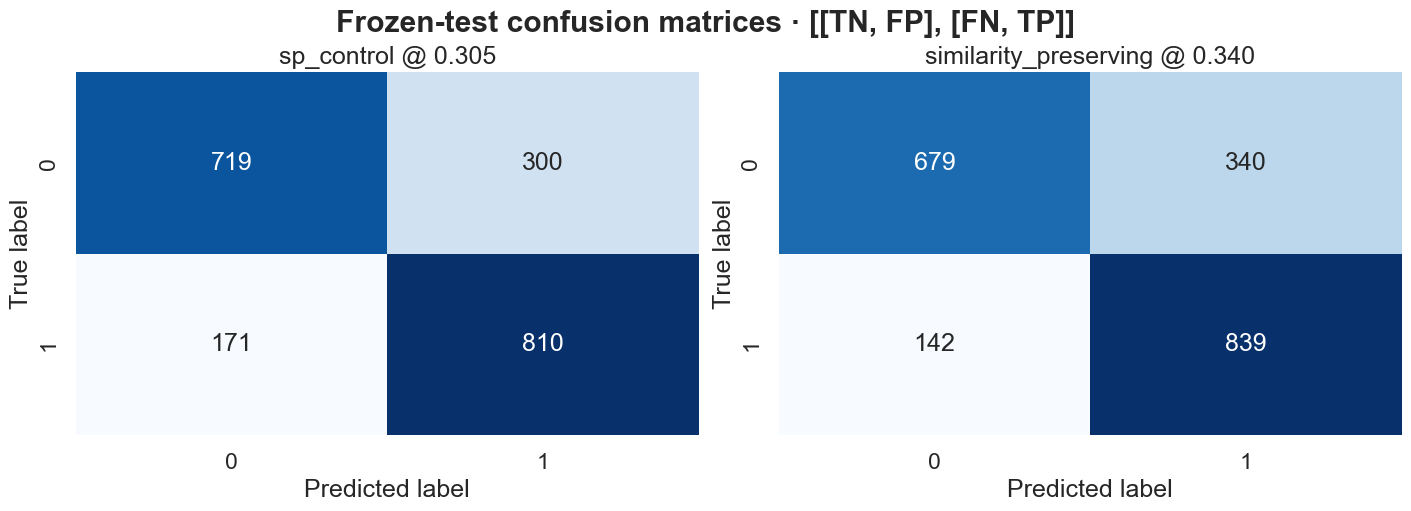

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
for axis, (name, row) in zip(axes, quality.set_index("model").iterrows()):
    matrix = np.asarray(row["confusion_matrix"])
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axis)
    axis.set(
        title=f"{name} @ {row.threshold:.3f}",
        xlabel="Predicted label",
        ylabel="True label",
    )
fig.suptitle("Frozen-test confusion matrices · [[TN, FP], [FN, TP]]", fontweight="bold")
fig.savefig(FIGURE_DIR / "spkd_confusion_matrices.png", dpi=180)
plt.show()

## 8 · Relation evidence: did SPKD actually copy teacher geometry?

In [45]:
diagnostic_count = int(config["evaluation"]["relation_diagnostic_samples"])
half = diagnostic_count // 2

diagnostic_frame = pd.concat(
    [
        splits["test"].query("label == 0").iloc[:half],
        splits["test"].query("label == 1").iloc[:half],
    ],
    ignore_index=True,
).sort_values("label", kind="stable").reset_index(drop=True)

diagnostic_inputs, diagnostic_labels = next(
    iter(
        make_dataset(
            diagnostic_frame,
            training=False,
            seed=SEED,
            batch_size=diagnostic_count,
        )
    )
)

control_model = tf.keras.models.load_model(models["sp_control"], compile=False)
sp_model = tf.keras.models.load_model(models["similarity_preserving"], compile=False)
teacher_features = feature_view(teacher, teacher_layer)
control_features = feature_view(control_model, student_layer)
sp_features = feature_view(sp_model, student_layer)

_, teacher_feature = teacher_features(diagnostic_inputs["teacher_image"], training=False)
_, control_feature = control_features(diagnostic_inputs["student_image"], training=False)
_, sp_feature = sp_features(diagnostic_inputs["student_image"], training=False)

relation_matrices = {
    "teacher": similarity_matrix(teacher_feature).numpy(),
    "sp_control": similarity_matrix(control_feature).numpy(),
    "similarity_preserving": similarity_matrix(sp_feature).numpy(),
}

In [46]:
def relation_statistics(
        name, 
        matrix, 
        teacher_matrix, 
        labels
):
    count = len(labels)
    diagonal = np.eye(count, dtype=bool)
    same_class = (labels[:, None] == labels[None, :]) & ~diagonal
    cross_class = labels[:, None] != labels[None, :]
    off_diagonal = ~diagonal
    return {
        "model": name,
        "paper_relation_mse": float(np.mean((matrix - teacher_matrix) ** 2)),
        "off_diagonal_relation_mse": float(
            np.mean((matrix[off_diagonal] - teacher_matrix[off_diagonal]) ** 2)
        ),
        "mean_same_class_similarity": float(matrix[same_class].mean()),
        "mean_cross_class_similarity": float(matrix[cross_class].mean()),
        "class_relation_margin": float(matrix[same_class].mean() - matrix[cross_class].mean()),
    }

In [47]:
labels_numpy = np.asarray(diagnostic_labels).reshape(-1).astype(int)
relation_rows = [
    relation_statistics(
        name,
        matrix,
        relation_matrices["teacher"],
        labels_numpy,
    )
    for name, matrix in relation_matrices.items()
]
relation_diagnostics = pd.DataFrame(relation_rows)
relation_diagnostics.to_csv(REPORT_DIR / "relation_diagnostics.csv", index=False)
display(relation_diagnostics)

,model,paper_relation_mse,off_diagonal_relation_mse,mean_same_class_similarity,mean_cross_class_similarity,class_relation_margin
0,teacher,0.000000,0.000000,0.154731,0.119477,0.035254
1,sp_control,0.003223,0.002034,0.169289,0.149879,0.019410
2,similarity_preserving,0.001227,0.001156,0.154582,0.126145,0.028436


In [48]:
teacher_relation = relation_matrices["teacher"]

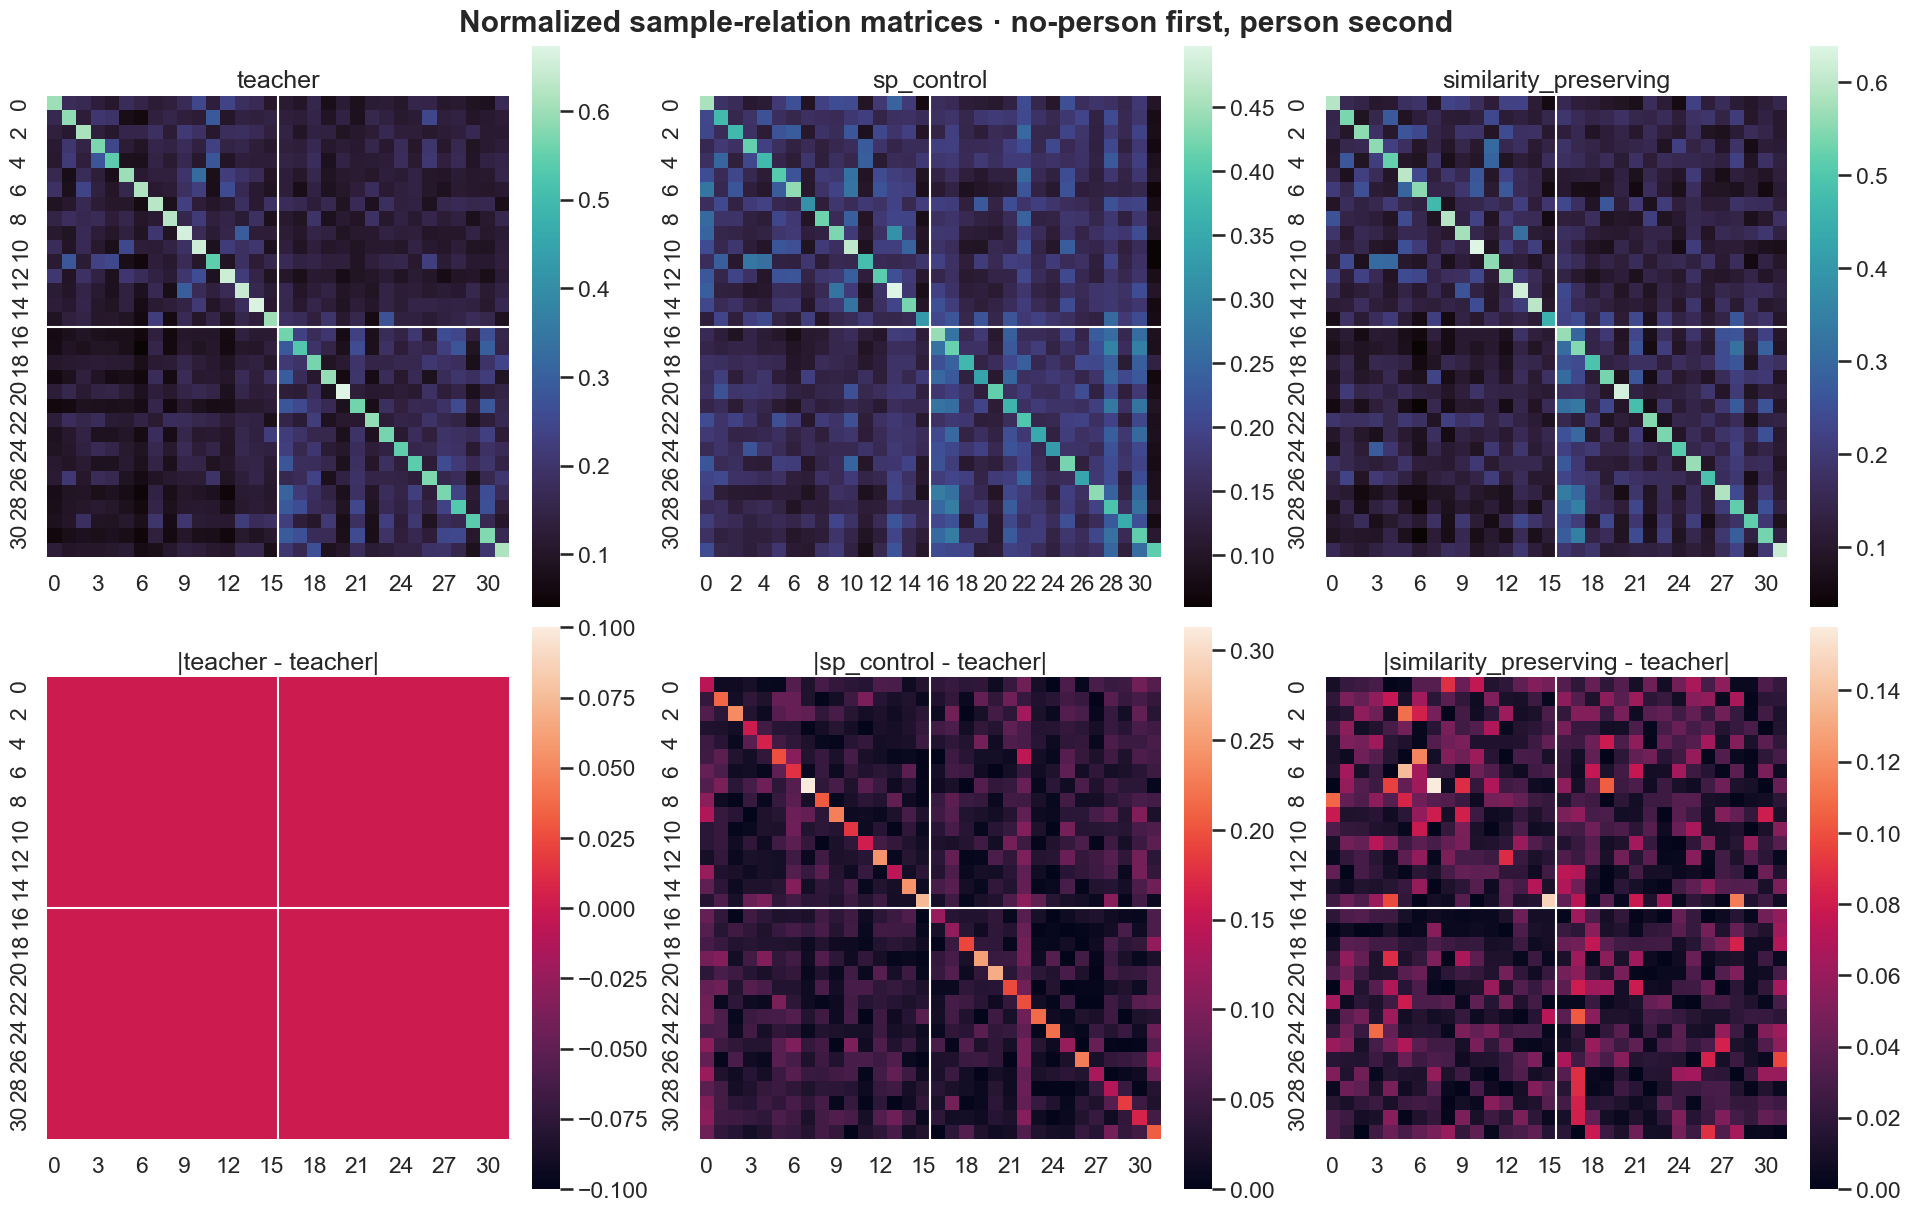

In [49]:
fig, axes = plt.subplots(2, 3, figsize=(19, 12), constrained_layout=True)
for axis, name in zip(axes[0], ("teacher", "sp_control", "similarity_preserving")):
    sns.heatmap(
        relation_matrices[name],
        cmap="mako",
        vmin=relation_matrices[name].min(),
        vmax=relation_matrices[name].max(),
        square=True,
        cbar=True,
        ax=axis,
    )
    axis.axhline(half, color="white", linewidth=1.5)
    axis.axvline(half, color="white", linewidth=1.5)
    axis.set_title(name)

for axis, name in zip(axes[1], ("teacher", "sp_control", "similarity_preserving")):
    difference = np.abs(relation_matrices[name] - teacher_relation)
    sns.heatmap(difference, cmap="rocket", vmin=0, square=True, cbar=True, ax=axis)
    axis.axhline(half, color="white", linewidth=1.5)
    axis.axvline(half, color="white", linewidth=1.5)
    axis.set_title(f"|{name} - teacher|")

fig.suptitle(
    "Normalized sample-relation matrices · no-person first, person second",
    fontweight="bold",
)
fig.savefig(FIGURE_DIR / "spkd_relation_matrices.png", dpi=180)
plt.show()

### Relation diagnostic interpretation

- `paper_relation_mse` is exactly the paper loss on this fixed diagnostic batch.
- `off_diagonal_relation_mse` removes the trivial self-similarity diagonal and is often easier to
  interpret.
- `class_relation_margin` is descriptive only. SPKD never directly optimizes this label-derived
  quantity.
- One batch is not sufficient evidence. The classification metrics and paired bootstrap remain
  the promotion evidence; the heatmap answers whether the intended mechanism occurred.

## 9 · Graph identity, internal gates, and project-champion gate

In [50]:
graph_rows = []
for name, model_path in models.items():
    model = tf.keras.models.load_model(model_path, compile=False)
    _, _, profile = profile_model(model, batch_size=1, training_batch_size=BATCH_SIZE)
    graph_rows.append(
        {
            "model": name,
            "parameters": profile["parameters"],
            "macs": profile["estimated_macs_batch1"],
            "peak_int8_activation": profile[
                "peak_live_activation_int8_bytes_batch1_hypothetical"
            ],
        }
    )
graph = pd.DataFrame(graph_rows)
graph.to_csv(REPORT_DIR / "graph_identity.csv", index=False)
display(graph)

,model,parameters,macs,peak_int8_activation
0,sp_control,218801,10487648,117136
1,similarity_preserving,218801,10487648,117136


In [51]:
quality_by_model = quality.set_index("model")
control_row = quality_by_model.loc["sp_control"]
candidate_row = quality_by_model.loc["similarity_preserving"]

champion_quality = pd.read_csv(paths["champion_quality"])
champion_row = champion_quality.set_index("model").loc["same_view_lambda0"]

relation_by_model = relation_diagnostics.set_index("model")
relation_gain = (
    relation_by_model.loc["sp_control", "paper_relation_mse"]
    - relation_by_model.loc["similarity_preserving", "paper_relation_mse"]
)

gates = {
    "internal_pr_auc_gain": bool(
        candidate_row.pr_auc
        >= control_row.pr_auc
        + float(config["acceptance_gate"]["minimum_pr_auc_gain_over_control"])
    ),
    "internal_f1_retained": bool(
        candidate_row.f1
        >= control_row.f1
        - float(config["acceptance_gate"]["maximum_f1_drop_from_control"])
    ),
    "internal_specificity_retained": bool(
        candidate_row.specificity
        >= control_row.specificity
        - float(config["acceptance_gate"]["maximum_specificity_drop_from_control"])
    ),
    "relation_alignment_gain": bool(
        relation_gain
        > float(config["acceptance_gate"]["minimum_relation_alignment_gain"])
    ),
    "graph_identity": bool(graph.drop(columns="model").nunique().max() == 1),
    "champion_pr_auc_matched": bool(
        candidate_row.pr_auc
        >= champion_row.pr_auc
        - float(config["acceptance_gate"]["maximum_pr_auc_drop_from_champion"])
    ),
    "champion_f1_matched": bool(
        candidate_row.f1
        >= champion_row.f1
        - float(config["acceptance_gate"]["maximum_f1_drop_from_champion"])
    ),
}
gates["accepted_internal"] = all(
    gates[key]
    for key in (
        "internal_pr_auc_gain",
        "internal_f1_retained",
        "internal_specificity_retained",
        "relation_alignment_gain",
        "graph_identity",
    )
)
gates["accepted_project"] = bool(
    gates["accepted_internal"]
    and gates["champion_pr_auc_matched"]
    and gates["champion_f1_matched"]
)

comparison = pd.DataFrame(
    [
        {"model": "sp_control", **control_row.to_dict()},
        {"model": "similarity_preserving", **candidate_row.to_dict()},
        {"model": "notebook03_champion", **champion_row.to_dict()},
    ]
)
comparison.to_csv(REPORT_DIR / "project_model_comparison.csv", index=False)
(REPORT_DIR / "acceptance_gates.json").write_text(
    json.dumps(gates, indent=2), encoding="utf-8"
)
display(comparison[["model", "accuracy", "precision", "recall", "specificity", "f1", "pr_auc"]])
display(pd.Series(gates))

,model,accuracy,precision,recall,specificity,f1,pr_auc
0,sp_control,0.7645,0.729730,0.825688,0.705594,0.774749,0.862016
1,similarity_preserving,0.7590,0.711620,0.855250,0.666340,0.776852,0.863601
2,notebook03_champion,0.7815,0.777551,0.776758,0.786065,0.777155,0.865103


internal_pr_auc_gain              True
internal_f1_retained              True
internal_specificity_retained    False
relation_alignment_gain           True
graph_identity                    True
champion_pr_auc_matched          False
champion_f1_matched              False
accepted_internal                False
accepted_project                 False
dtype: bool

The two decisions are intentionally separate:

1. **Internal acceptance** asks whether SPKD beats its exact hard-label causal control and visibly
   improves relation alignment.
2. **Project acceptance** asks whether the resulting model also matches the best earlier
   Student-120. A weak local control cannot promote a globally inferior model.

## 10 · Conditional full-INT8 export and desktop parity

In [52]:
TFLITE_PATH = MODEL_DIR / config["export"]["model_filename"]


def representative_dataset():
    emitted = 0
    for images, _ in val_dataset:
        for image in images:
            yield [image.numpy()[None].astype(np.float32)]
            emitted += 1
            if emitted >= int(config["export"]["representative_samples"]):
                return


# Export after internal acceptance to measure quantization parity. Physical deployment remains
# blocked unless the stricter project gate also passes.
if gates["accepted_internal"] and RUN_INT8_EXPORT:
    candidate = tf.keras.models.load_model(models["similarity_preserving"], compile=False)
    convert_full_integer(candidate, representative_dataset(), TFLITE_PATH)
    export_info = inspect_tflite(TFLITE_PATH)
    (REPORT_DIR / "export_info.json").write_text(
        json.dumps(export_info, indent=2), encoding="utf-8"
    )
    display(pd.Series(export_info))
else:
    export_info = None
    print("INT8 export skipped: internal SPKD gates did not pass.")

INT8 export skipped: internal SPKD gates did not pass.


In [53]:
def predict_tflite(path, dataset):
    interpreter = tf.lite.Interpreter(model_path=str(path))
    interpreter.allocate_tensors()
    input_detail = interpreter.get_input_details()[0]
    output_detail = interpreter.get_output_details()[0]
    input_scale, input_zero = input_detail["quantization"]
    output_scale, output_zero = output_detail["quantization"]
    labels, outputs = [], []

    for images, batch_labels in dataset:
        labels.extend(np.asarray(batch_labels).reshape(-1).astype(int))
        for image in np.asarray(images):
            quantized = np.clip(
                np.round(image / input_scale + input_zero), -128, 127
            ).astype(np.int8)[None]
            interpreter.set_tensor(input_detail["index"], quantized)
            interpreter.invoke()
            raw = interpreter.get_tensor(output_detail["index"])[0, 0]
            outputs.append((float(raw) - output_zero) * output_scale)
    return np.asarray(labels), np.asarray(outputs)

In [54]:
if export_info:
    _, int8_validation_probability = predict_tflite(TFLITE_PATH, val_dataset)
    _, int8_test_probability = predict_tflite(TFLITE_PATH, test_dataset)
    int8_threshold = select_threshold(
        validation_labels,
        int8_validation_probability,
        objective=config["evaluation"]["threshold_objective"],
        minimum_recall=float(config["evaluation"]["minimum_recall"]),
        false_positive_cost=float(config["evaluation"]["false_positive_cost"]),
        false_negative_cost=float(config["evaluation"]["false_negative_cost"]),
    )["threshold"]
    int8_metrics = classification_metrics(test_labels, int8_test_probability, int8_threshold)
    parity = {
        "probability_mae": float(
            np.mean(
                np.abs(
                    int8_test_probability - probabilities["similarity_preserving"]
                )
            )
        ),
        "f1_delta": float(int8_metrics["f1"] - candidate_row.f1),
        "pr_auc_delta": float(int8_metrics["pr_auc"] - candidate_row.pr_auc),
    }
    parity["passed"] = bool(
        parity["probability_mae"]
        <= float(config["acceptance_gate"]["maximum_float_to_int8_probability_mae"])
    )
    gates["int8_parity"] = parity["passed"]
    gates["eligible_for_device"] = bool(gates["accepted_project"] and parity["passed"])
    (REPORT_DIR / "int8_metrics.json").write_text(
        json.dumps(int8_metrics, indent=2), encoding="utf-8"
    )
    (REPORT_DIR / "float_to_int8_parity.json").write_text(
        json.dumps(parity, indent=2), encoding="utf-8"
    )
    display(pd.Series({"int8_threshold": int8_threshold, **int8_metrics}))
    display(pd.Series(parity))
else:
    int8_metrics = None
    parity = None
    gates["int8_parity"] = False
    gates["eligible_for_device"] = False

(REPORT_DIR / "acceptance_gates.json").write_text(
    json.dumps(gates, indent=2), encoding="utf-8"
)

352

## 11 · Hardware-efficiency interpretation and device hand-off

In [55]:
hardware_summary = pd.DataFrame(
    [
        {
            "model": name,
            "parameters": int(graph.set_index("model").loc[name, "parameters"]),
            "estimated_macs_batch1": int(graph.set_index("model").loc[name, "macs"]),
            "estimated_peak_int8_activation_bytes": int(
                graph.set_index("model").loc[name, "peak_int8_activation"]
            ),
            "tflite_bytes": int(export_info["size_bytes"])
            if name == "similarity_preserving" and export_info
            else np.nan,
            "esp32_cam_invoke_ms": np.nan,
            "esp32_s3_invoke_ms": np.nan,
            "measured_tensor_arena_bytes": np.nan,
            "evidence": "static desktop estimate; physical fields pending",
        }
        for name in models
    ]
)
hardware_summary.to_csv(REPORT_DIR / "hardware_summary.csv", index=False)
display(hardware_summary)

,model,parameters,estimated_macs_batch1,estimated_peak_int8_activation_bytes,tflite_bytes,esp32_cam_invoke_ms,esp32_s3_invoke_ms,measured_tensor_arena_bytes,evidence
0,sp_control,218801,10487648,117136,NaN,NaN,NaN,NaN,static desktop estimate; physical fields pending
1,similarity_preserving,218801,10487648,117136,NaN,NaN,NaN,NaN,static desktop estimate; physical fields pending


SPKD is a training-only technique. With graph identity, it cannot reduce ESP32 latency, tensor
arena, model flash, or MAC count relative to the hard control. A physical difference between these
two branches would be measurement noise unless their exported flatbuffers differ structurally.

Device flashing is intentionally gated by `eligible_for_device`. If it is true, the next device
step must record ESP32-CAM and ESP32-S3 separately: capture/preprocessing/invoke/postprocessing
latency, sustained FPS, tensor-arena use, SRAM/PSRAM/flash, and the exact firmware/model hashes.
Flash illumination must remain disabled during profiling.

## 12 · Final machine-readable and Markdown reports

In [56]:
def json_default(value):
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return float(value)
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, Path):
        return str(value)
    raise TypeError(type(value).__name__)


summary = {
    "experiment": config["project"]["name"],
    "paper_algorithm": {
        "method": "Similarity-Preserving Knowledge Distillation",
        "teacher_layer": teacher_layer,
        "student_layer": student_layer,
        "relation": "row-L2-normalized sample Gram matrix",
        "loss": "mean squared teacher/student relation difference",
        "gamma": GAMMA,
    },
    "contract": contract,
    "gamma_calibration": gamma_audit,
    "quality": quality.to_dict("records"),
    "project_comparison": comparison.to_dict("records"),
    "bootstrap": bootstrap_summary.to_dict("records"),
    "relation_diagnostics": relation_diagnostics.to_dict("records"),
    "graph": graph.to_dict("records"),
    "gates": gates,
    "int8_export": export_info,
    "int8_metrics": int8_metrics,
    "float_to_int8_parity": parity,
    "physical_profile_complete": False,
}
(REPORT_DIR / "experiment_summary.json").write_text(
    json.dumps(summary, indent=2, default=json_default), encoding="utf-8"
)

report_lines = [
    "# Similarity-Preserving KD report",
    "",
    f"- Calibrated gamma: **{GAMMA:.6g}**",
    f"- Internal causal acceptance: **{gates['accepted_internal']}**",
    f"- Project champion acceptance: **{gates['accepted_project']}**",
    f"- Eligible for physical device: **{gates['eligible_for_device']}**",
    "- Physical profiling complete: **False**",
    "",
    "## Frozen-test quality",
    "",
    quality.to_markdown(index=False),
    "",
    "## Relation diagnostics",
    "",
    relation_diagnostics.to_markdown(index=False),
    "",
    "## Project comparison",
    "",
    comparison[["model", "accuracy", "precision", "recall", "specificity", "f1", "pr_auc"]].to_markdown(index=False),
    "",
    "## Gates",
    "",
    pd.Series(gates, name="passed").to_markdown(),
    "",
]
(REPORT_DIR / "SIMILARITY_PRESERVING_REPORT.md").write_text(
    "\n".join(report_lines), encoding="utf-8"
)
print(REPORT_DIR / "SIMILARITY_PRESERVING_REPORT.md")

/Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32/artifacts/distillation/similarity_preserving_student_120/reports/SIMILARITY_PRESERVING_REPORT.md


## Final decision guide

- **Internal and project gates pass:** retain the INT8 model, run both physical board profiles,
  and compare measured latency/memory only with graph-equivalent Student-120 models.
- **Relation alignment improves but predictive quality does not:** the mechanism worked but the
  teacher geometry was not useful enough for binary VWW; do not increase `gamma` blindly.
- **Predictive quality improves but relation alignment does not:** inspect implementation, batch
  composition, and sampling variance before attributing the gain to SPKD.
- **Internal pass but project fail:** record the technique result, do not promote or deploy it, and
  move to the next relation method only if the remaining teacher/student geometry gap justifies
  the extra training complexity.
- **Both fail:** preserve the negative result. Do not combine SPKD with response KD until this
  isolated experiment is understood.